SONAR — Detecting Mines vs Rocks using Artificial Neural Networks (ANN)

In [2]:
!pip install scikeras
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Keras Wrapper
from scikeras.wrappers import KerasClassifier

In [3]:
# Load dataset
df = pd.read_csv("sonardataset.csv", header=None)

# Display first 5 rows
print(df.head())

       0       1       2       3       4       5       6       7       8   \
0     x_1     x_2     x_3     x_4     x_5     x_6     x_7     x_8     x_9   
1    0.02  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
2  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
3  0.0262  0.0582  0.1099  0.1083  0.0974   0.228  0.2431  0.3771  0.5598   
4    0.01  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   

       9   ...      51      52      53      54      55      56      57  \
0    x_10  ...    x_52    x_53    x_54    x_55    x_56    x_57    x_58   
1  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167   0.018  0.0084   
2  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191   0.014  0.0049   
3  0.6194  ...  0.0232  0.0166  0.0095   0.018  0.0244  0.0316  0.0164   
4  0.1264  ...  0.0121  0.0036   0.015  0.0085  0.0073   0.005  0.0044   

       58      59 60  
0    x_59    x_60  Y  
1   0.009  0.0032  R  
2  0.0052  0.0044  R  


In [4]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (209, 61)


In [5]:
print(df.isnull().sum())

0     0
1     0
2     0
3     0
4     0
     ..
56    0
57    0
58    0
59    0
60    0
Length: 61, dtype: int64


In [6]:
print(df[60].value_counts())

60
M    111
R     97
Y      1
Name: count, dtype: int64


In [7]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [9]:
#Convert:
#M → 1
#R → 0

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [11]:
df = pd.read_csv("sonardataset.csv")

In [12]:
print(df.head())
print(df.columns)

      x_1     x_2     x_3     x_4     x_5     x_6     x_7     x_8     x_9  \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

     x_10  ...    x_52    x_53    x_54    x_55    x_56    x_57    x_58  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

     x_59    x_60  Y  
0  0.0090  0.0032  R  
1  0.0052  0.0044  R  
2  0.0095  0.0078  R  


In [13]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [14]:
X = X.apply(pd.to_numeric)

In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
print(X.dtypes)

x_1     float64
x_2     float64
x_3     float64
x_4     float64
x_5     float64
x_6     float64
x_7     float64
x_8     float64
x_9     float64
x_10    float64
x_11    float64
x_12    float64
x_13    float64
x_14    float64
x_15    float64
x_16    float64
x_17    float64
x_18    float64
x_19    float64
x_20    float64
x_21    float64
x_22    float64
x_23    float64
x_24    float64
x_25    float64
x_26    float64
x_27    float64
x_28    float64
x_29    float64
x_30    float64
x_31    float64
x_32    float64
x_33    float64
x_34    float64
x_35    float64
x_36    float64
x_37    float64
x_38    float64
x_39    float64
x_40    float64
x_41    float64
x_42    float64
x_43    float64
x_44    float64
x_45    float64
x_46    float64
x_47    float64
x_48    float64
x_49    float64
x_50    float64
x_51    float64
x_52    float64
x_53    float64
x_54    float64
x_55    float64
x_56    float64
x_57    float64
x_58    float64
x_59    float64
x_60    float64
dtype: object


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
#Architecture
#Input Layer → 60 neurons
#Hidden Layer → 32 neurons
#Output Layer → 1 neuron

model = Sequential()

# Hidden Layer
model.add(Dense(32, activation='relu', input_shape=(60,)))

# Dropout
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.6894 - loss: 0.6992 - val_accuracy: 0.7647 - val_loss: 0.6185
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6742 - loss: 0.6853 - val_accuracy: 0.7647 - val_loss: 0.5736
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6894 - loss: 0.6106 - val_accuracy: 0.7353 - val_loss: 0.5285
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7273 - loss: 0.5515 - val_accuracy: 0.7353 - val_loss: 0.4975
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7273 - loss: 0.4949 - val_accuracy: 0.7353 - val_loss: 0.4792
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7803 - loss: 0.5058 - val_accuracy: 0.7353 - val_loss: 0.4629
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7727 - loss: 0.4485 - val_accuracy: 0.7647 - val_loss: 0.4570
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7727 - loss: 0.4296 - val_accuracy: 0.7647 - val_loss:

In [22]:
y_pred_prob = model.predict(X_test)

# Convert probabilities into classes
y_pred = (y_pred_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


In [24]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.9333333333333333
Recall: 0.7
F1 Score: 0.8


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.95      0.86        22
           1       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42



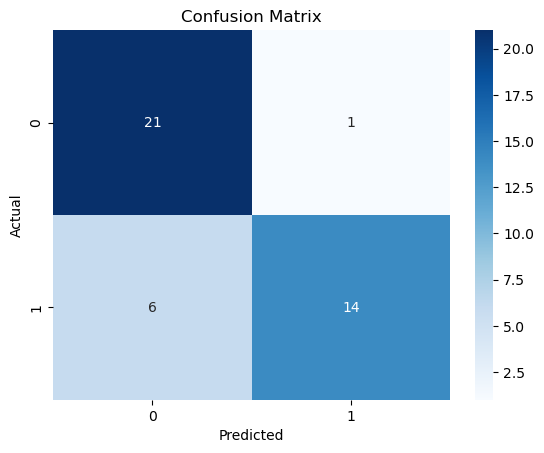

In [26]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
def create_model(neurons=32, activation='relu', learning_rate=0.001):

    model = Sequential()

    model.add(Dense(neurons,
                    activation=activation,
                    input_shape=(60,)))

    model.add(Dropout(0.2))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [28]:
model = KerasClassifier(
    model=create_model,
    verbose=0
)

In [29]:
param_grid = {
    'model__neurons': [16, 32, 64],
    'model__activation': ['relu', 'tanh'],
    'model__learning_rate': [0.001, 0.01],
    'batch_size': [8, 16],
    'epochs': [50, 100]
}

In [33]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy'
)

grid_result = grid.fit(X_train, y_train)

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs

In [34]:
print("Best Accuracy:", grid_result.best_score_)
print("Best Parameters:", grid_result.best_params_)

Best Accuracy: 0.8318181818181817
Best Parameters: {'batch_size': 16, 'epochs': 100, 'model__activation': 'relu', 'model__learning_rate': 0.001, 'model__neurons': 16}


In [36]:
best_model = grid_result.best_estimator_

y_pred = best_model.predict(X_test)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.78      0.95      0.86        22
           1       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42

